# Setup

In [11]:
import math
import pathlib

import torch
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import umap
import seaborn as sns

from data import MET_Data
import utils
import align

In [12]:
data_dir = pathlib.Path("data")

In [13]:
merge_map = utils.get_tree_merge_map(data_dir / "meta/tree_Mouse_ALM-VISp_2018.csv", "n3")
def get_merge_func(index, merge_map = merge_map):
    merge_func = np.vectorize(lambda elem: merge_map[elem][index]) 
    return merge_func

def get_gaussian_data(num_clusters, num_samples, data_dim, mean_scale = 1.0, cluster_scale = 0.1, num_datasets = 2, rotate = False):
    ortho_gen = stats.ortho_group(data_dim)
    means = [np.random.normal(scale = mean_scale, size = [1, data_dim]) for _ in range(num_clusters)]
    variances = [np.random.normal(scale = cluster_scale, size = [num_samples, data_dim]) for _ in range(num_clusters)]
    transforms = [(ortho_gen.rvs() if rotate else np.eye(data_dim)) for _ in range(num_datasets)]
    clusters = [sum(vals) for vals in zip(means, variances)]
    raw_datasets = [np.concatenate(clusters, 0) @ transform for transform in transforms]
    datasets = [data - data.mean(0) for data in raw_datasets]
    labels = np.concatenate([np.full([num_samples], i) for i in range(num_clusters)])
    return (datasets, labels)

def get_L_data(num_samples, angle):
    angle = math.pi/15
    X = torch.zeros([num_samples, 2])
    num_vert = num_samples // 2
    X[:num_vert, 1] = torch.linspace(0, 2, num_vert)
    X[:num_vert, 0] = 0.1*torch.rand(size = [num_vert])
    X[num_vert:, 0] = torch.linspace(0, 2, num_samples - num_vert)
    X[num_vert:, 1] = 0.1*torch.rand(size = [num_samples - num_vert])
    Y = X @ torch.as_tensor([[math.cos(angle), -math.sin(angle)], [math.sin(angle), math.cos(angle)]])
    return ([X, Y], [torch.zeros([num_samples]), torch.zeros([num_samples])])

def get_arbor_data():
    data_keys = {"arbors": [["patchseq", "arbors"], ["EM", "arbors"]]}
    met_data = MET_Data({"patchseq": data_dir / "patchseq.hdf5", "EM": data_dir / "EM.hdf5"}, **data_keys)
    patch_data = met_data.query(formats = [("arbors",)], platforms = ["patchseq"], outputs = ["class", "arbors"])
    em_data = met_data.query(formats = [("arbors",)], platforms = ["EM"], outputs = ["class", "arbors"])
    (patch_samples, em_samples) = (patch_data["arbors"], em_data["arbors"])
    (patch_labels, em_labels) = (patch_data["class"], em_data["class"])
    return ([patch_samples, em_samples], [patch_labels, em_labels])

def get_morph_data(neuron_class = "exc"):
    data_keys = {"morphometric": [["patchseq", "morphometric"], ["EM", "morphometric"]]}
    met_data = MET_Data({"patchseq": data_dir / "patchseq.hdf5", "EM": data_dir / "EM.hdf5"}, **data_keys)
    patch_data = met_data.query(formats = [("morphometric",)], platforms = ["patchseq"], classes = [neuron_class], outputs = ["class", "morphometric"])
    em_data = met_data.query(formats = [("morphometric",)], platforms = ["EM"], classes = [neuron_class], outputs = ["class", "morphometric"])
    valid_features = np.all(~np.isnan(em_data["morphometric"]), 0)
    (patch_samples, em_samples) = (patch_data["morphometric"], em_data["morphometric"])
    (patch_samples, em_samples) = (patch_samples[:, valid_features], em_samples[:, valid_features])
    (patch_labels, em_labels) = (patch_data["class"], em_data["class"])
    return ([patch_samples, em_samples], [patch_labels, em_labels])

def get_gene_data():
    data_paths = {"patchseq": data_dir / "patchseq.hdf5", "smartseq": data_dir / "smartseq.hdf5"}
    data_keys = {"logcpm": [["patchseq", "logcpm"], ["smartseq", "logcpm"]]}
    met_data = MET_Data(data_paths, **data_keys)
    patch_data = met_data.query(formats = [("logcpm",)], platforms = ["patchseq"], outputs = ["cluster_label", "logcpm"])
    smart_data = met_data.query(formats = [("logcpm",)], platforms = ["smartseq"], outputs = ["cluster_label", "logcpm"])
    (patch_samples, smart_samples) = (patch_data["logcpm"], smart_data["logcpm"])
    (patch_labels, smart_labels) = (patch_data["cluster_label"], smart_data["cluster_label"])
    return ([patch_samples, smart_samples], [patch_labels, smart_labels])

def get_10x_data():
    data_keys = {"logcpm": [["trunc", "logcpm"], ["10x", "logcpm"]]}
    met_data = MET_Data({"trunc": data_dir / "patch_smart_trunc.hdf5", "10x": data_dir / "10x.hdf5"}, **data_keys)
    patch_data = met_data.query(formats = [("logcpm",)], platforms = ["patchseq"], outputs = ["cluster_label", "logcpm"])
    x10_data = met_data.query(formats = [("logcpm",)], platforms = ["10x"], outputs = ["cluster_label", "logcpm"])
    (patch_samples, x10_samples) = (patch_data["logcpm"], x10_data["logcpm"])
    (patch_labels, x10_labels) = (patch_data["cluster_label"], x10_data["cluster_label"])
    return ([patch_samples, x10_samples], [patch_labels, x10_labels])

# Data

In [15]:
(datasets, labels) = get_gene_data() #get_arbor_data() #get_L_data(patch_samples, math.pi/15)
# datasets[1] = np.tile(datasets[1], (10, 1))
datasets = [torch.as_tensor(arr).flatten(1) for arr in datasets]
normalize = False
batch_size = 32

In [16]:
(ref, query) = (ref_in, query_in) = datasets
if normalize:
    (ref_in, query_in) = (ref / torch.linalg.norm(ref, dim = 1, keepdim = True), query / torch.linalg.norm(query, dim = 1, keepdim = True))
print("Determining neighborhood...")
mutual_neighbors = align.get_mutual_neighbors(ref_in, query_in, 5, batch_size)
print("Completed.                           ")


Determining neighborhood...
Completed.                           


In [17]:
print("Computing correction...")
(correction, nearest_anchors) = align.get_correction(ref, query, mutual_neighbors, 100, 1.0, batch_size)
query_corr = query + correction
print("Completed.                           ")

Computing correction...
Completed.                           


## Data Plots

In [18]:
cell_pairs = mutual_neighbors
(ref_anchors, query_anchors, query_anchors_corr) = (ref[mutual_neighbors[:, 0]], query[mutual_neighbors[:, 1]], query_corr[mutual_neighbors[:, 1]])
ref_anchors_orig = ref_anchors_corr = ref_anchors
query_anchors_orig = query_anchors
(orig_comb, corr_comb) = (torch.cat([query, ref]), torch.cat([query_corr, ref]))
if ref_anchors.shape[-1] > 2:
    orig_map = umap.UMAP(min_dist = 0.55).fit(orig_comb)
    corr_map = umap.UMAP(min_dist = 0.55).fit(corr_comb)
    ref_anchors_orig = orig_map.transform(ref_anchors)
    ref_anchors_corr = corr_map.transform(ref_anchors)
    query_anchors_orig = orig_map.transform(query_anchors)
    query_anchors_corr = corr_map.transform(query_anchors_corr)
    orig_comb = orig_map.transform(orig_comb)
    corr_comb = corr_map.transform(corr_comb)

## L

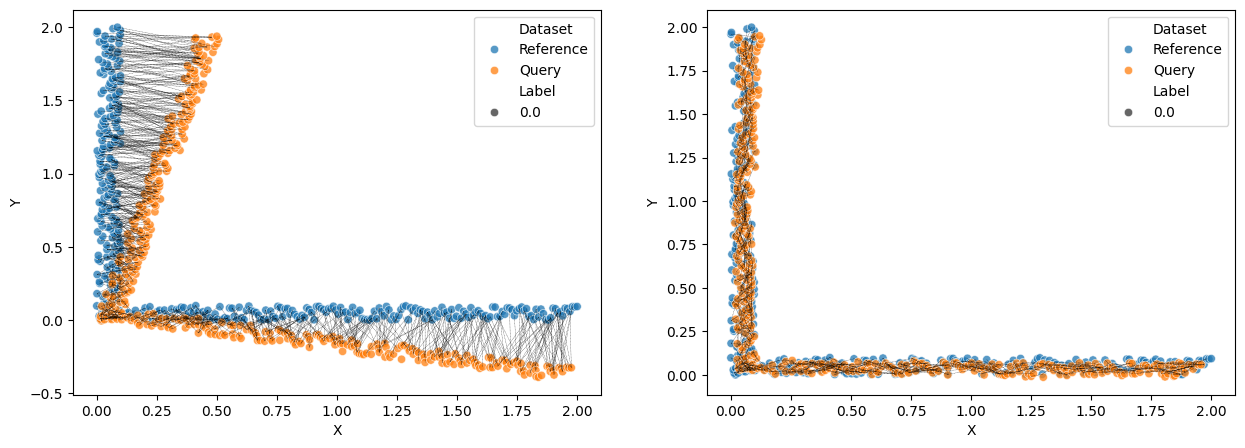

In [ ]:
pair_plot_frac = 0.1
orig_data = {
    "Dataset": len(ref)*["Reference"] + len(query)*["Query"],
    "Label": torch.cat(labels).tolist(),
    "X": orig_comb[:, 0].tolist(), "Y": orig_comb[:, 1].tolist()}
corr_data = {
    "Dataset": len(ref)*["Reference"] + len(query)*["Query"],
    "Label": torch.cat(labels).tolist(),
    "X": corr_comb[:, 0].tolist(), "Y": corr_comb[:, 1].tolist()}
(fig, (ax_orig, ax_corr)) = plt.subplots(1, 2, figsize = (15, 5))
sns.scatterplot(orig_data, ax = ax_orig, x = "X", y = "Y", hue = "Dataset", style = "Label", alpha = 0.75)
sns.scatterplot(corr_data, ax = ax_corr, x = "X", y = "Y", hue = "Dataset", style = "Label", alpha = 0.75)
if pair_plot_frac > 0:
    pair_i = torch.multinomial(torch.ones([len(mutual_neighbors)]), int(pair_plot_frac*len(mutual_neighbors)))
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_orig[pair_i], query_anchors_orig[pair_i]):
        ax_orig.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_corr[pair_i], query_anchors_corr[pair_i]):
        ax_corr.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
plt.show()

## Morphometric

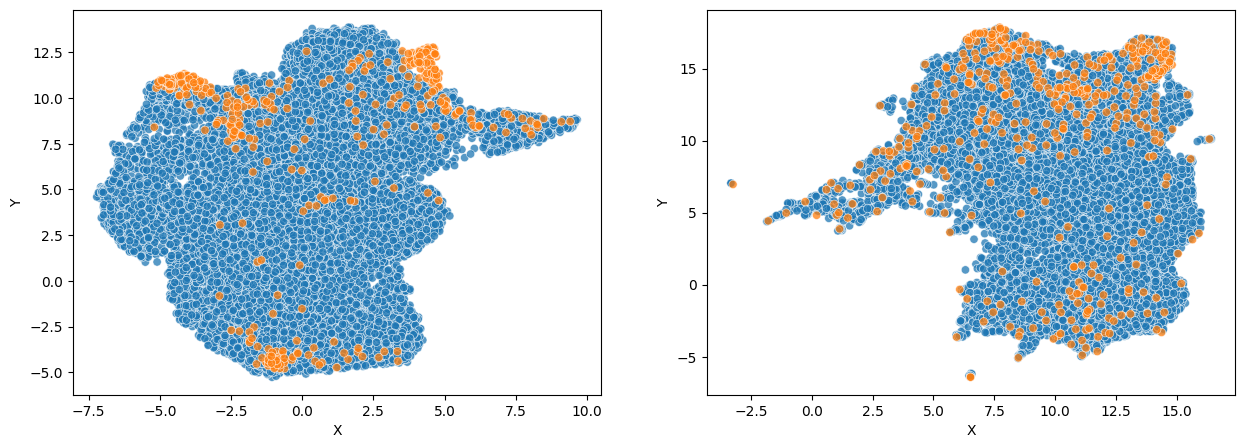

In [25]:
pair_plot_frac = 0.0
orig_data = {
    "Dataset": len(query)*["Query"] + len(ref)*["Reference"],
    "X": orig_comb[:, 0].tolist(), "Y": orig_comb[:, 1].tolist()}
corr_data = {
    "Dataset": len(query)*["Query"] + len(ref)*["Reference"],
    "X": corr_comb[:, 0].tolist(), "Y": corr_comb[:, 1].tolist()}
(fig, (ax_orig, ax_corr)) = plt.subplots(1, 2, figsize = (15, 5))
sns.scatterplot(orig_data, ax = ax_orig, x = "X", y = "Y", hue = "Dataset", alpha = 0.75)
sns.scatterplot(corr_data, ax = ax_corr, x = "X", y = "Y", hue = "Dataset", alpha = 0.75)
if pair_plot_frac > 0:
    pair_i = torch.multinomial(torch.ones([len(mutual_neighbors)]), int(pair_plot_frac*len(mutual_neighbors)))
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_orig[pair_i], query_anchors_orig[pair_i]):
        ax_orig.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_corr[pair_i], query_anchors_corr[pair_i]):
        ax_corr.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
ax_orig.legend([],[], frameon=False)
ax_corr.legend([],[], frameon=False)
plt.show()

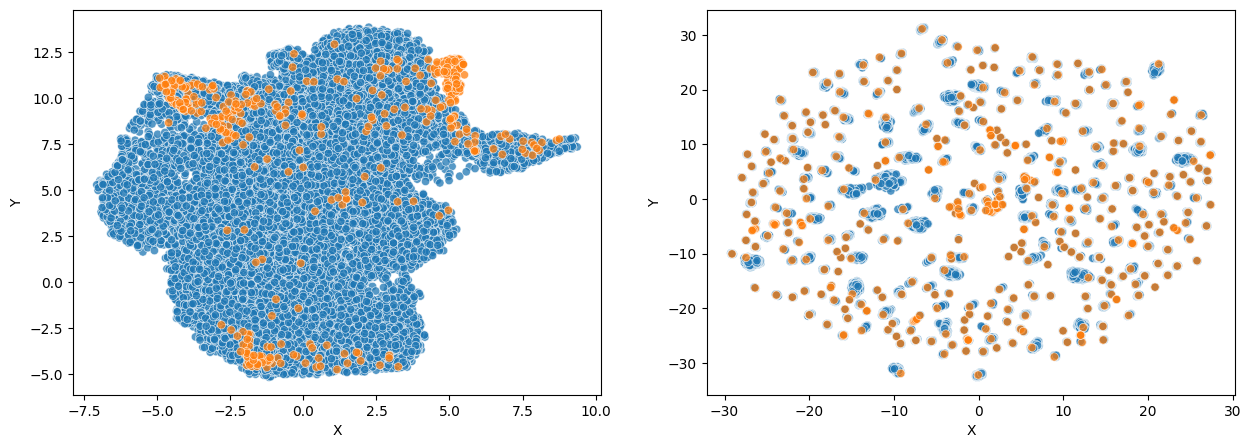

In [ ]:
pair_plot_frac = 0.0
orig_data = {
    "Dataset": len(query)*["Query"] + len(ref)*["Reference"],
    "X": orig_comb[:, 0].tolist(), "Y": orig_comb[:, 1].tolist()}
corr_data = {
    "Dataset": len(query)*["Query"] + len(ref)*["Reference"],
    "X": corr_comb[:, 0].tolist(), "Y": corr_comb[:, 1].tolist()}
(fig, (ax_orig, ax_corr)) = plt.subplots(1, 2, figsize = (15, 5))
sns.scatterplot(orig_data, ax = ax_orig, x = "X", y = "Y", hue = "Dataset", alpha = 0.75)
sns.scatterplot(corr_data, ax = ax_corr, x = "X", y = "Y", hue = "Dataset", alpha = 0.75)
if pair_plot_frac > 0:
    pair_i = torch.multinomial(torch.ones([len(mutual_neighbors)]), int(pair_plot_frac*len(mutual_neighbors)))
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_orig[pair_i], query_anchors_orig[pair_i]):
        ax_orig.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_corr[pair_i], query_anchors_corr[pair_i]):
        ax_corr.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
ax_orig.legend([],[], frameon=False)
ax_corr.legend([],[], frameon=False)
plt.show()

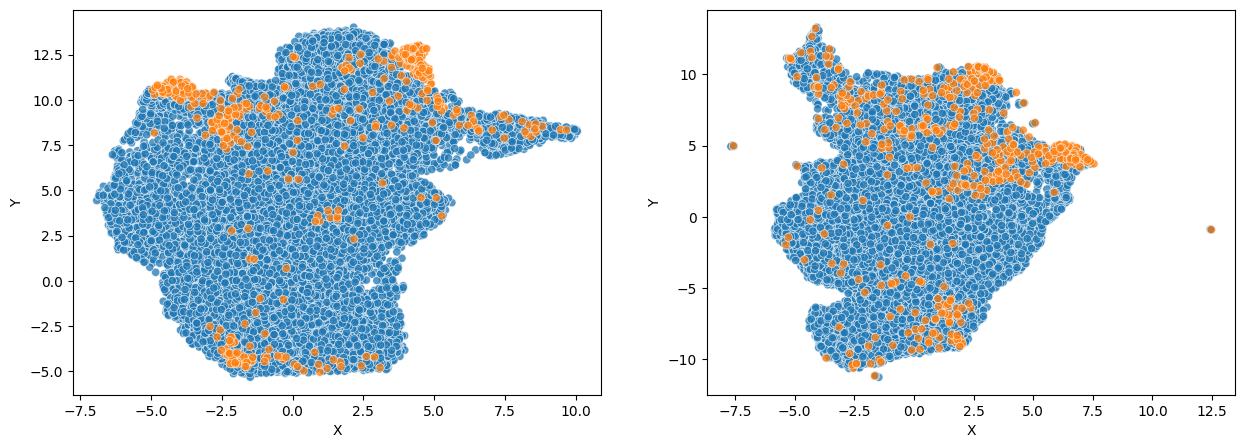

In [ ]:
pair_plot_frac = 0.0
orig_data = {
    "Dataset": len(query)*["Query"] + len(ref)*["Reference"],
    "X": orig_comb[:, 0].tolist(), "Y": orig_comb[:, 1].tolist()}
corr_data = {
    "Dataset": len(query)*["Query"] + len(ref)*["Reference"],
    "X": corr_comb[:, 0].tolist(), "Y": corr_comb[:, 1].tolist()}
(fig, (ax_orig, ax_corr)) = plt.subplots(1, 2, figsize = (15, 5))
sns.scatterplot(orig_data, ax = ax_orig, x = "X", y = "Y", hue = "Dataset", alpha = 0.75)
sns.scatterplot(corr_data, ax = ax_corr, x = "X", y = "Y", hue = "Dataset", alpha = 0.75)
if pair_plot_frac > 0:
    pair_i = torch.multinomial(torch.ones([len(mutual_neighbors)]), int(pair_plot_frac*len(mutual_neighbors)))
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_orig[pair_i], query_anchors_orig[pair_i]):
        ax_orig.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_corr[pair_i], query_anchors_corr[pair_i]):
        ax_corr.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
ax_orig.legend([],[], frameon=False)
ax_corr.legend([],[], frameon=False)
plt.show()

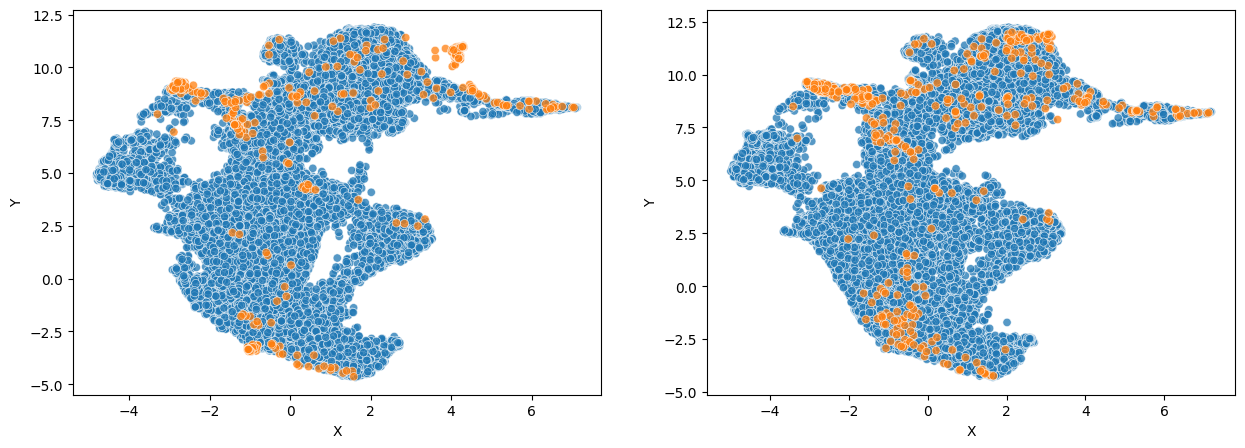

In [ ]:
pair_plot_frac = 0.0
orig_data = {
    "Dataset": len(ref)*["Reference"] + len(query)*["Query"],
    "X": orig_comb[:, 0].tolist(), "Y": orig_comb[:, 1].tolist()}
corr_data = {
    "Dataset": len(ref)*["Reference"] + len(query)*["Query"],
    "X": corr_comb[:, 0].tolist(), "Y": corr_comb[:, 1].tolist()}
(fig, (ax_orig, ax_corr)) = plt.subplots(1, 2, figsize = (15, 5))
sns.scatterplot(orig_data, ax = ax_orig, x = "X", y = "Y", hue = "Dataset", alpha = 0.75)
sns.scatterplot(corr_data, ax = ax_corr, x = "X", y = "Y", hue = "Dataset", alpha = 0.75)
if pair_plot_frac > 0:
    pair_i = torch.multinomial(torch.ones([len(mutual_neighbors)]), int(pair_plot_frac*len(mutual_neighbors)))
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_orig[pair_i], query_anchors_orig[pair_i]):
        ax_orig.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_corr[pair_i], query_anchors_corr[pair_i]):
        ax_corr.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
ax_orig.legend([],[], frameon=False)
ax_corr.legend([],[], frameon=False)
plt.show()

## Arbors

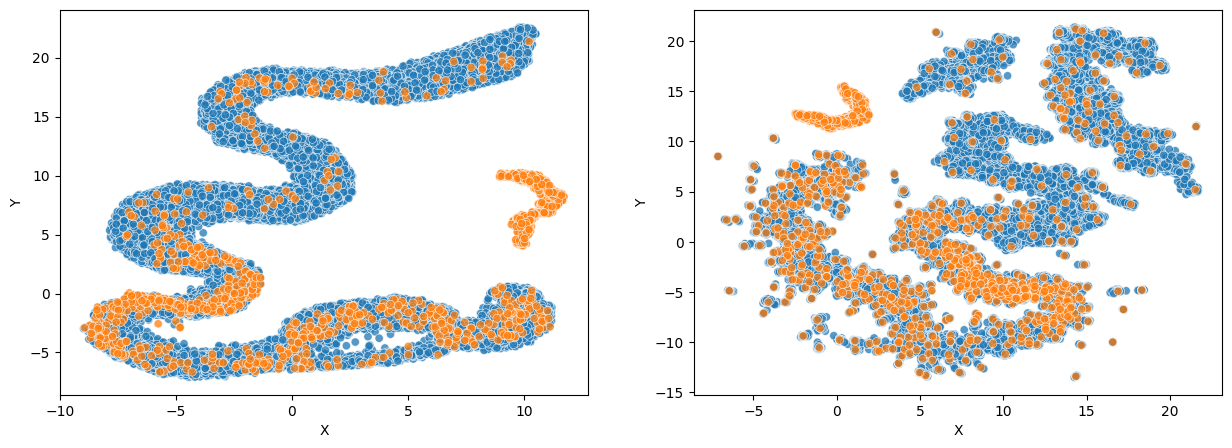

In [ ]:
pair_plot_frac = 0.0
orig_data = {
    "Dataset": len(query)*["Query"] + len(ref)*["Reference"],
    "X": orig_comb[:, 0].tolist(), "Y": orig_comb[:, 1].tolist()}
corr_data = {
    "Dataset": len(query)*["Query"] + len(ref)*["Reference"],
    "X": corr_comb[:, 0].tolist(), "Y": corr_comb[:, 1].tolist()}
(fig, (ax_orig, ax_corr)) = plt.subplots(1, 2, figsize = (15, 5))
sns.scatterplot(orig_data, ax = ax_orig, x = "X", y = "Y", hue = "Dataset", alpha = 0.75)
sns.scatterplot(corr_data, ax = ax_corr, x = "X", y = "Y", hue = "Dataset", alpha = 0.75)
if pair_plot_frac > 0:
    pair_i = torch.multinomial(torch.ones([len(mutual_neighbors)]), int(pair_plot_frac*len(mutual_neighbors)))
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_orig[pair_i], query_anchors_orig[pair_i]):
        ax_orig.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_corr[pair_i], query_anchors_corr[pair_i]):
        ax_corr.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
ax_orig.legend([],[], frameon=False)
ax_corr.legend([],[], frameon=False)
plt.show()

## Transcriptomic

In [39]:
clusters = get_merge_func(-20)(np.char.strip(np.concatenate(labels[::-1], 0)))

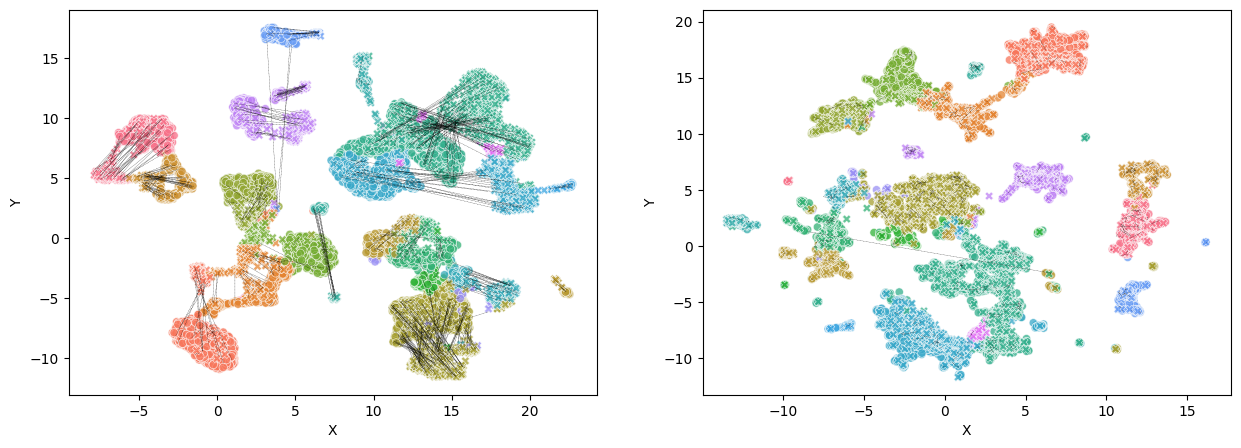

In [41]:
pair_plot_frac = 0.2
orig_data = {
    "Dataset": len(query)*["Query"] + len(ref)*["Reference"],
    "Label": clusters.tolist(),
    "X": orig_comb[:, 0].tolist(), "Y": orig_comb[:, 1].tolist()}
corr_data = {
    "Dataset": len(query)*["Query"] + len(ref)*["Reference"],
    "Label": clusters.tolist(),
    "X": corr_comb[:, 0].tolist(), "Y": corr_comb[:, 1].tolist()}
(fig, (ax_orig, ax_corr)) = plt.subplots(1, 2, figsize = (15, 5))
sns.scatterplot(orig_data, ax = ax_orig, x = "X", y = "Y", hue = "Label", style = "Dataset", alpha = 0.75)
sns.scatterplot(corr_data, ax = ax_corr, x = "X", y = "Y", hue = "Label", style = "Dataset", alpha = 0.75)
if pair_plot_frac > 0:
    pair_i = torch.multinomial(torch.ones([len(mutual_neighbors)]), int(pair_plot_frac*len(mutual_neighbors)))
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_orig[pair_i], query_anchors_orig[pair_i]):
        ax_orig.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_corr[pair_i], query_anchors_corr[pair_i]):
        ax_corr.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
ax_orig.legend([],[], frameon=False)
ax_corr.legend([],[], frameon=False)
plt.show()

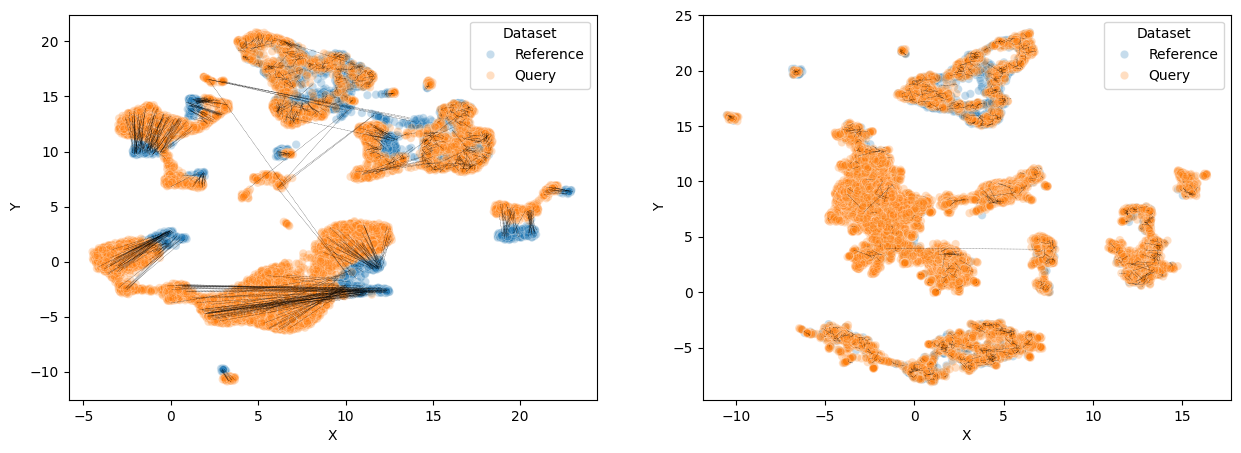

In [ ]:
pair_plot_frac = 0.2
orig_data = {
    "Dataset": len(query)*["Query"] + len(ref)*["Reference"],
    "X": orig_comb[:, 0].tolist(), "Y": orig_comb[:, 1].tolist()}
corr_data = {
    "Dataset": len(query)*["Query"] + len(ref)*["Reference"],
    "X": corr_comb[:, 0].tolist(), "Y": corr_comb[:, 1].tolist()}
(fig, (ax_orig, ax_corr)) = plt.subplots(1, 2, figsize = (15, 5))
sns.scatterplot(orig_data, ax = ax_orig, x = "X", y = "Y", hue = "Dataset", alpha = 0.75)
sns.scatterplot(corr_data, ax = ax_corr, x = "X", y = "Y", hue = "Dataset", alpha = 0.75)
if pair_plot_frac > 0:
    pair_i = torch.multinomial(torch.ones([len(mutual_neighbors)]), int(pair_plot_frac*len(mutual_neighbors)))
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_orig[pair_i], query_anchors_orig[pair_i]):
        ax_orig.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
    for ((r_x, r_y), (q_x, q_y)) in zip(ref_anchors_corr[pair_i], query_anchors_corr[pair_i]):
        ax_corr.plot([r_x, q_x], [r_y, q_y], color = "black", linestyle = "dashed", linewidth = 0.2)
# ax_orig.legend([],[], frameon=False)
# ax_corr.legend([],[], frameon=False)
plt.show()